In [6]:
# ==========================================================
# HIGH-ACCURACY FEW-SHOT (CONVNEXT + MIXUP)
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
import os
import gc

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.metrics import accuracy_score
from collections import defaultdict

# ========================
# SEED
# ========================
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ========================
# DATASET
# ========================
def find_dataset(root="/kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset"):
    for sub in os.listdir(root):
        path = os.path.join(root, sub)
        if os.path.isdir(path):
            return path

DATASET_PATH = find_dataset()
print("Dataset:", DATASET_PATH)

# ========================
# STRONG AUGMENTATION
# ========================
transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.4,0.4,0.4,0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

dataset = ImageFolder(DATASET_PATH, transform=transform)
num_classes = len(dataset.classes)

# ========================
# SPLIT
# ========================
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(dataset.samples):
    class_indices[label].append(idx)

train_pool, val_indices = [], []

for label, samples in class_indices.items():
    random.shuffle(samples)
    split = int(0.8 * len(samples))
    train_pool.extend(samples[:split])
    val_indices.extend(samples[split:])

# ========================
# MODEL
# ========================
def get_model():
    try:
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        print("Pretrained loaded")
    except:
        model = convnext_tiny(weights=None)

    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

    return model.to(device)

# ========================
# MIXUP
# ========================
def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# ========================
# TRAIN
# ========================
def run(K):

    print(f"\n==== {K}-SHOT ====")

    train_idx = []

    per_class = defaultdict(list)
    for idx in train_pool:
        _, label = dataset.samples[idx]
        per_class[label].append(idx)

    for label, samples in per_class.items():
        random.shuffle(samples)
        train_idx.extend(samples[:min(K, len(samples))])

    labels = [dataset.samples[i][1] for i in train_idx]
    class_count = np.bincount(labels, minlength=num_classes)
    weights = 1. / (class_count + 1e-6)
    sample_weights = [weights[l] for l in labels]

    sampler = WeightedRandomSampler(sample_weights,
                                    num_samples=len(sample_weights),
                                    replacement=True)

    train_loader = DataLoader(Subset(dataset, train_idx),
                              batch_size=32, sampler=sampler)

    val_loader = DataLoader(Subset(dataset, val_indices),
                            batch_size=32, shuffle=False)

    model = get_model()

    # Fine-tune full model (important)
    for p in model.parameters():
        p.requires_grad = True

    optimizer = optim.AdamW(model.parameters(), lr=3e-4)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    epochs = 15 + K//2

    best_acc = 0

    for epoch in range(epochs):

        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            # MIXUP
            x, y_a, y_b, lam = mixup(x, y)

            optimizer.zero_grad()
            outputs = model(x)
            loss = lam * criterion(outputs, y_a) + (1-lam) * criterion(outputs, y_b)
            loss.backward()
            optimizer.step()

        # VALIDATION
        model.eval()
        preds, labs = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                out = model(x)
                pred = torch.argmax(out, 1).cpu().numpy()

                preds.extend(pred)
                labs.extend(y.numpy())

        acc = accuracy_score(labs, preds) * 100

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(),
                       f"/kaggle/working/convnext_{K}.pth")

        print(f"Epoch {epoch+1}: {acc:.2f}% | Best: {best_acc:.2f}%")

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return best_acc

# ========================
# RUN
# ========================
SHOTS = [5,10,20,30,40]

results = {}

for k in SHOTS:
    results[k] = run(k)

print("\nFINAL RESULTS")
for k,v in results.items():
    print(f"{k}-SHOT → {v:.2f}%")

Device: cuda
Dataset: /kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset/ovarian_ultrasound_dataset

==== 5-SHOT ====
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 200MB/s] 


Pretrained loaded
Epoch 1: 46.77% | Best: 46.77%
Epoch 2: 46.77% | Best: 46.77%
Epoch 3: 30.65% | Best: 46.77%
Epoch 4: 48.39% | Best: 48.39%
Epoch 5: 59.68% | Best: 59.68%
Epoch 6: 51.61% | Best: 59.68%
Epoch 7: 56.45% | Best: 59.68%
Epoch 8: 77.42% | Best: 77.42%
Epoch 9: 46.77% | Best: 77.42%
Epoch 10: 58.06% | Best: 77.42%
Epoch 11: 56.45% | Best: 77.42%
Epoch 12: 72.58% | Best: 77.42%
Epoch 13: 61.29% | Best: 77.42%
Epoch 14: 70.97% | Best: 77.42%
Epoch 15: 67.74% | Best: 77.42%
Epoch 16: 66.13% | Best: 77.42%
Epoch 17: 62.90% | Best: 77.42%

==== 10-SHOT ====
Pretrained loaded
Epoch 1: 38.71% | Best: 38.71%
Epoch 2: 20.97% | Best: 38.71%
Epoch 3: 62.90% | Best: 62.90%
Epoch 4: 72.58% | Best: 72.58%
Epoch 5: 64.52% | Best: 72.58%
Epoch 6: 61.29% | Best: 72.58%
Epoch 7: 62.90% | Best: 72.58%
Epoch 8: 69.35% | Best: 72.58%
Epoch 9: 50.00% | Best: 72.58%
Epoch 10: 53.23% | Best: 72.58%
Epoch 11: 61.29% | Best: 72.58%
Epoch 12: 56.45% | Best: 72.58%
Epoch 13: 67.74% | Best: 72.58%
Epo

In [7]:
# ==========================================================
# TESTING CODE (FINAL EVALUATION)
# ==========================================================

import torch
import torch.nn as nn
import os

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import convnext_tiny
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# TEST DATASET PATH
# ========================
TEST_PATH = "/kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset"

def find_test(root):
    for sub in os.listdir(root):
        path = os.path.join(root, sub)
        if os.path.isdir(path):
            return path

TEST_PATH = find_test(TEST_PATH)
print("Test Path:", TEST_PATH)

# ========================
# TEST TRANSFORM (NO AUGMENTATION!)
# ========================
test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_dataset = ImageFolder(TEST_PATH, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(test_dataset.classes)
print("Classes:", test_dataset.classes)

# ========================
# MODEL LOADER
# ========================
def load_model(path):

    model = convnext_tiny(weights=None)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device)
    model.eval()

    return model

# ========================
# EVALUATION FUNCTION
# ========================
def evaluate(model):

    preds = []
    labels = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            out = model(x)
            pred = torch.argmax(out, 1).cpu().numpy()

            preds.extend(pred)
            labels.extend(y.numpy())

    acc = accuracy_score(labels, preds) * 100

    print(f"\nAccuracy: {acc:.2f}%")
    print("\nClassification Report:\n")
    print(classification_report(labels, preds, target_names=test_dataset.classes))

    print("\nConfusion Matrix:\n")
    print(confusion_matrix(labels, preds))

    return acc

# ========================
# TEST ALL MODELS
# ========================
SHOTS = [5,10,20,30,40]

results = {}

for k in SHOTS:
    model_path = f"/kaggle/working/convnext_{k}.pth"

    if not os.path.exists(model_path):
        print(f"Model {k}-shot not found, skipping...")
        continue

    print(f"\n===== TESTING {k}-SHOT MODEL =====")

    model = load_model(model_path)
    acc = evaluate(model)

    results[k] = acc

# ========================
# FINAL TEST RESULTS
# ========================
print("\n===== FINAL TEST RESULTS =====")
for k, v in results.items():
    print(f"{k}-SHOT → {v:.2f}%")

Test Path: /kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset/ovarian_ultrasound_dataset
Classes: ['Dominant_Follicle', 'Normal', 'PCO']

===== TESTING 5-SHOT MODEL =====

Accuracy: 73.09%

Classification Report:

                   precision    recall  f1-score   support

Dominant_Follicle       0.72      0.82      0.77       144
           Normal       1.00      0.76      0.86        41
              PCO       0.66      0.61      0.64       116

         accuracy                           0.73       301
        macro avg       0.80      0.73      0.76       301
     weighted avg       0.74      0.73      0.73       301


Confusion Matrix:

[[118   0  26]
 [  0  31  10]
 [ 45   0  71]]

===== TESTING 10-SHOT MODEL =====

Accuracy: 88.37%

Classification Report:

                   precision    recall  f1-score   support

Dominant_Follicle       0.90      0.91      0.90       144
           Normal       1.00      0.78      0.88        41
              PCO       0.84 

In [8]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Classes found: ['Normal', 'PCO', 'Dominant_Follicle']


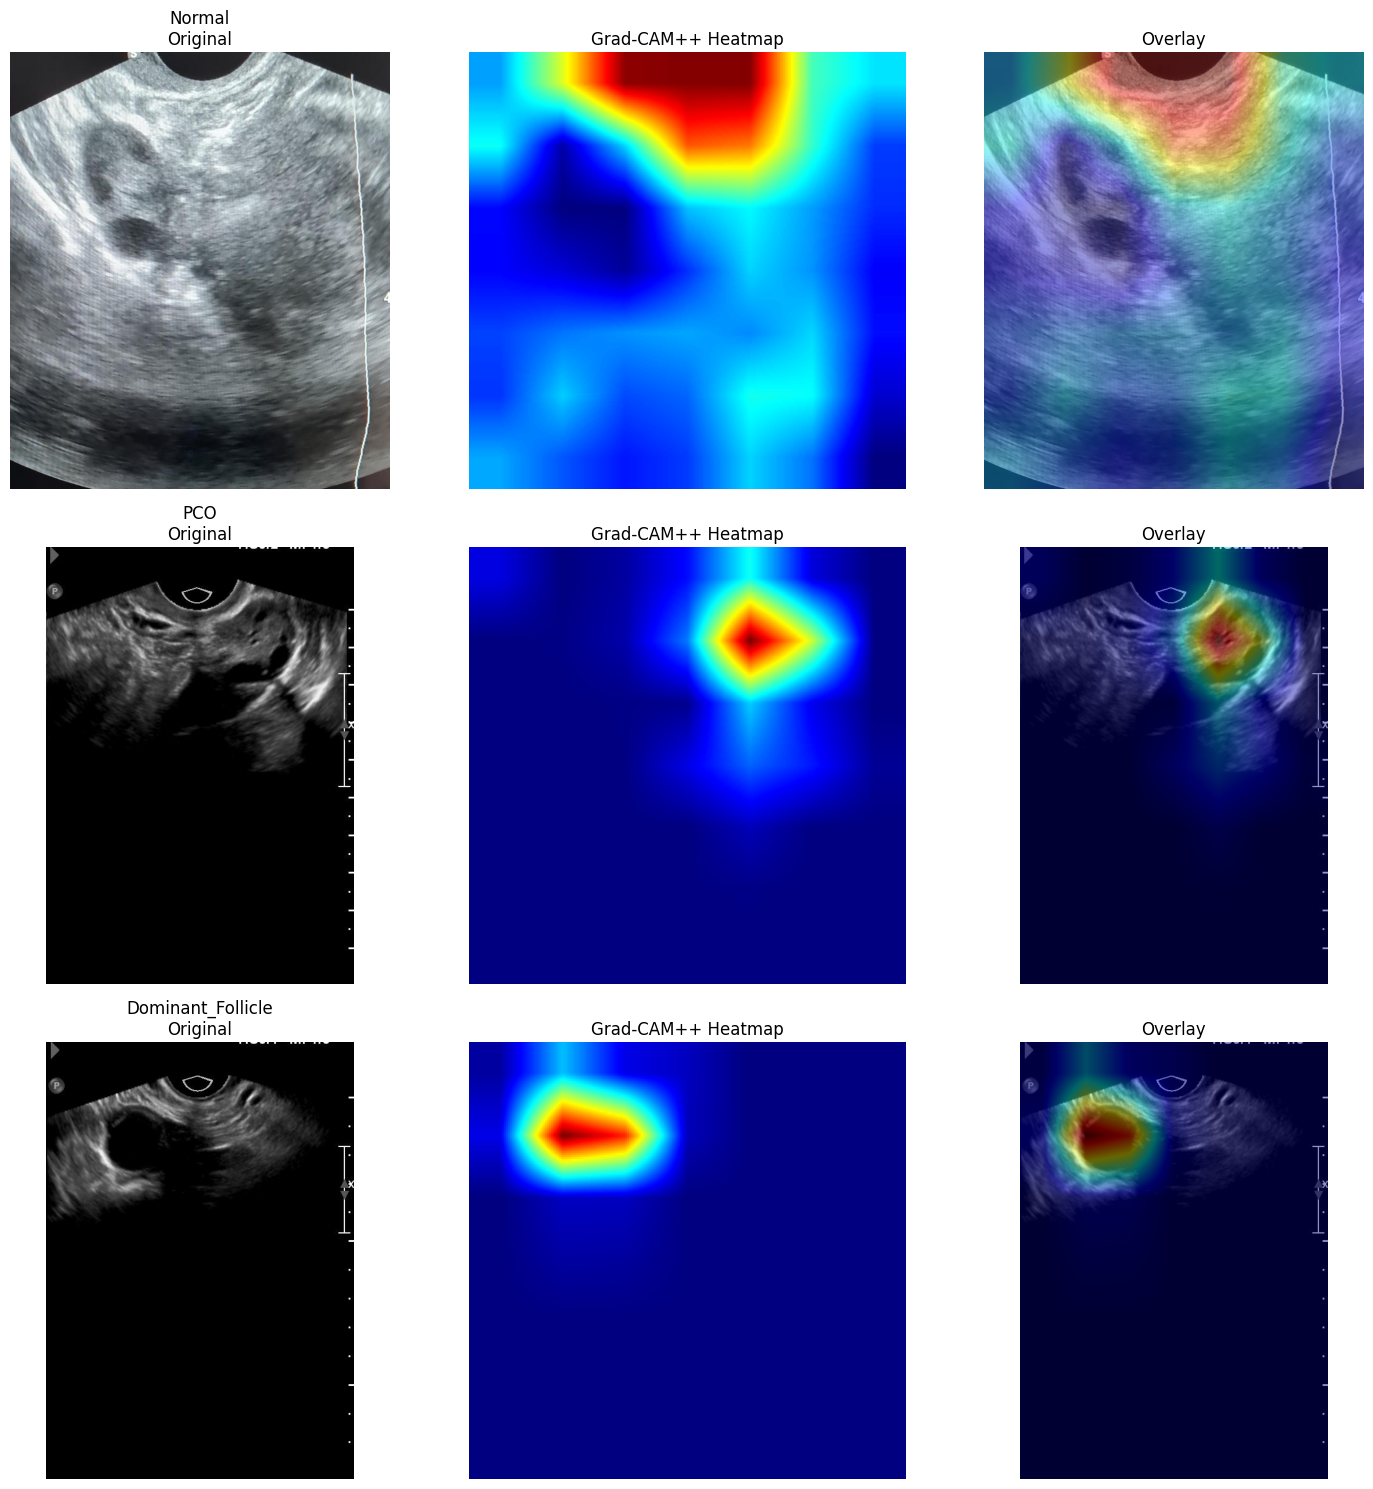

In [12]:
# ==========================================================
# GRAD-CAM++ FOR EACH CLASS (ORIGINAL | HEATMAP | OVERLAY)
# ==========================================================

import torch
import torch.nn as nn
import numpy as np
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.models import convnext_tiny
from pytorch_grad_cam import GradCAMPlusPlus

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# PATHS
# ========================
MODEL_PATH = "/kaggle/working/convnext_40.pth"
DATASET_ROOT = "/kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset"

# ========================
# FIND ONE IMAGE PER CLASS
# ========================
def get_images_per_class(root):
    class_images = {}

    for root_dir, dirs, files in os.walk(root):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                class_name = os.path.basename(root_dir)

                if class_name not in class_images:
                    class_images[class_name] = os.path.join(root_dir, file)

    return class_images

class_images = get_images_per_class(DATASET_ROOT)

if len(class_images) == 0:
    raise RuntimeError("❌ No images found")

print("Classes found:", list(class_images.keys()))

# ========================
# TRANSFORM
# ========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# LOAD MODEL
# ========================
def load_model(path):
    checkpoint = torch.load(path, map_location=device)

    model = convnext_tiny(weights=None)
    num_classes = checkpoint["classifier.2.weight"].shape[0]

    model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    model.load_state_dict(checkpoint)

    model = model.to(device)
    model.eval()

    return model

model = load_model(MODEL_PATH)

# ========================
# GRAD-CAM++
# ========================
target_layers = [model.features[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# ========================
# PROCESS EACH CLASS
# ========================
plt.figure(figsize=(15, 5 * len(class_images)))

row = 1

for class_name, img_path in class_images.items():

    # LOAD IMAGE
    img = Image.open(img_path).convert("RGB")
    img_original = np.array(img)

    # Resize for model
    img_resized = img.resize((224,224))
    img_np = np.array(img_resized).astype(np.float32) / 255.0

    input_tensor = transform(img).unsqueeze(0).to(device)

    # PREDICTION
    with torch.no_grad():
        output = model(input_tensor)
        pred_class = torch.argmax(output, dim=1).item()

    # GRAD-CAM++
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # HEATMAP (middle)
    heatmap = cv2.resize(grayscale_cam, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # OVERLAY (right)
    heatmap_full = cv2.resize(grayscale_cam,
                             (img_original.shape[1], img_original.shape[0]))
    heatmap_full = np.uint8(255 * heatmap_full)
    heatmap_full = cv2.applyColorMap(heatmap_full, cv2.COLORMAP_JET)

    overlay = heatmap_full * 0.4 + img_original * 0.6
    overlay = np.uint8(overlay)

    # ========================
    # PLOT
    # ========================
    plt.subplot(len(class_images), 3, row)
    plt.title(f"{class_name}\nOriginal")
    plt.imshow(img_original)
    plt.axis("off")

    plt.subplot(len(class_images), 3, row+1)
    plt.title("Grad-CAM++ Heatmap")
    plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(len(class_images), 3, row+2)
    plt.title("Overlay")
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    row += 3

plt.tight_layout()
plt.show()

In [14]:
# ==========================================================
# PROFESSIONAL GRAD-CAM++ (3 RANDOM IMAGES PER CLASS)
# WITH PREDICTION + CONFIDENCE
# ==========================================================

import torch
import torch.nn as nn
import numpy as np
import os
import cv2
import random
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.models import convnext_tiny
from pytorch_grad_cam import GradCAMPlusPlus

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# PATHS
# ========================
MODEL_PATH = "/kaggle/working/convnext_40.pth"
DATASET_ROOT = "/kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset"

# ========================
# TRANSFORM
# ========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# LOAD MODEL
# ========================
def load_model(path):
    checkpoint = torch.load(path, map_location=device)

    model = convnext_tiny(weights=None)
    num_classes = checkpoint["classifier.2.weight"].shape[0]

    model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    model.load_state_dict(checkpoint)

    model = model.to(device)
    model.eval()

    return model

model = load_model(MODEL_PATH)

# ========================
# CLASS NAMES
# ========================
def get_classes(root):
    for sub in os.listdir(root):
        path = os.path.join(root, sub)
        if os.path.isdir(path):
            return sorted(os.listdir(path))

classes = get_classes(DATASET_ROOT)
print("Classes:", classes)

# ========================
# GET 3 RANDOM IMAGES PER CLASS
# ========================
def get_random_images(root, num=3):
    class_images = {}

    for class_name in classes:
        class_path = os.path.join(root, class_name)
        if not os.path.isdir(class_path):
            continue

        images = [os.path.join(class_path, f)
                  for f in os.listdir(class_path)
                  if f.lower().endswith((".jpg",".png",".jpeg"))]

        if len(images) >= num:
            class_images[class_name] = random.sample(images, num)
        else:
            class_images[class_name] = images

    return class_images

data = get_random_images(DATASET_ROOT, 3)

# ========================
# GRAD-CAM++
# ========================
target_layers = [model.features[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# ========================
# PLOT
# ========================
rows = sum(len(v) for v in data.values())

plt.figure(figsize=(15, 5 * rows))
row = 1

for class_name, img_list in data.items():

    true_label_idx = classes.index(class_name)

    for img_path in img_list:

        # LOAD IMAGE
        img = Image.open(img_path).convert("RGB")
        img_original = np.array(img)

        img_resized = img.resize((224,224))
        img_np = np.array(img_resized).astype(np.float32) / 255.0

        input_tensor = transform(img).unsqueeze(0).to(device)

        # PREDICTION
        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            conf, pred = torch.max(probs, 1)

        pred_idx = pred.item()
        confidence = conf.item() * 100

        pred_label = classes[pred_idx]

        # GRAD-CAM++
        grayscale_cam = cam(input_tensor=input_tensor)[0]

        # HEATMAP (middle)
        heatmap = cv2.resize(grayscale_cam, (224,224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # OVERLAY (right)
        heatmap_full = cv2.resize(grayscale_cam,
                                 (img_original.shape[1], img_original.shape[0]))
        heatmap_full = np.uint8(255 * heatmap_full)
        heatmap_full = cv2.applyColorMap(heatmap_full, cv2.COLORMAP_JET)

        overlay = heatmap_full * 0.4 + img_original * 0.6
        overlay = np.uint8(overlay)

        # ========================
        # TITLES
        # ========================
        title_text = f"True: {class_name}\nPred: {pred_label}\nConf: {confidence:.2f}%"

        # ========================
        # PLOT
        # ========================
        plt.subplot(rows, 3, row)
        plt.title(title_text)
        plt.imshow(img_original)
        plt.axis("off")

        plt.subplot(rows, 3, row+1)
        plt.title("Grad-CAM++")
        plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.subplot(rows, 3, row+2)
        plt.title("Overlay")
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        row += 3

plt.tight_layout()
plt.show()

Classes: ['Dominant_Follicle', 'Normal', 'PCO']


<Figure size 1500x0 with 0 Axes>

Classes: ['Dominant_Follicle', 'Normal', 'PCO']


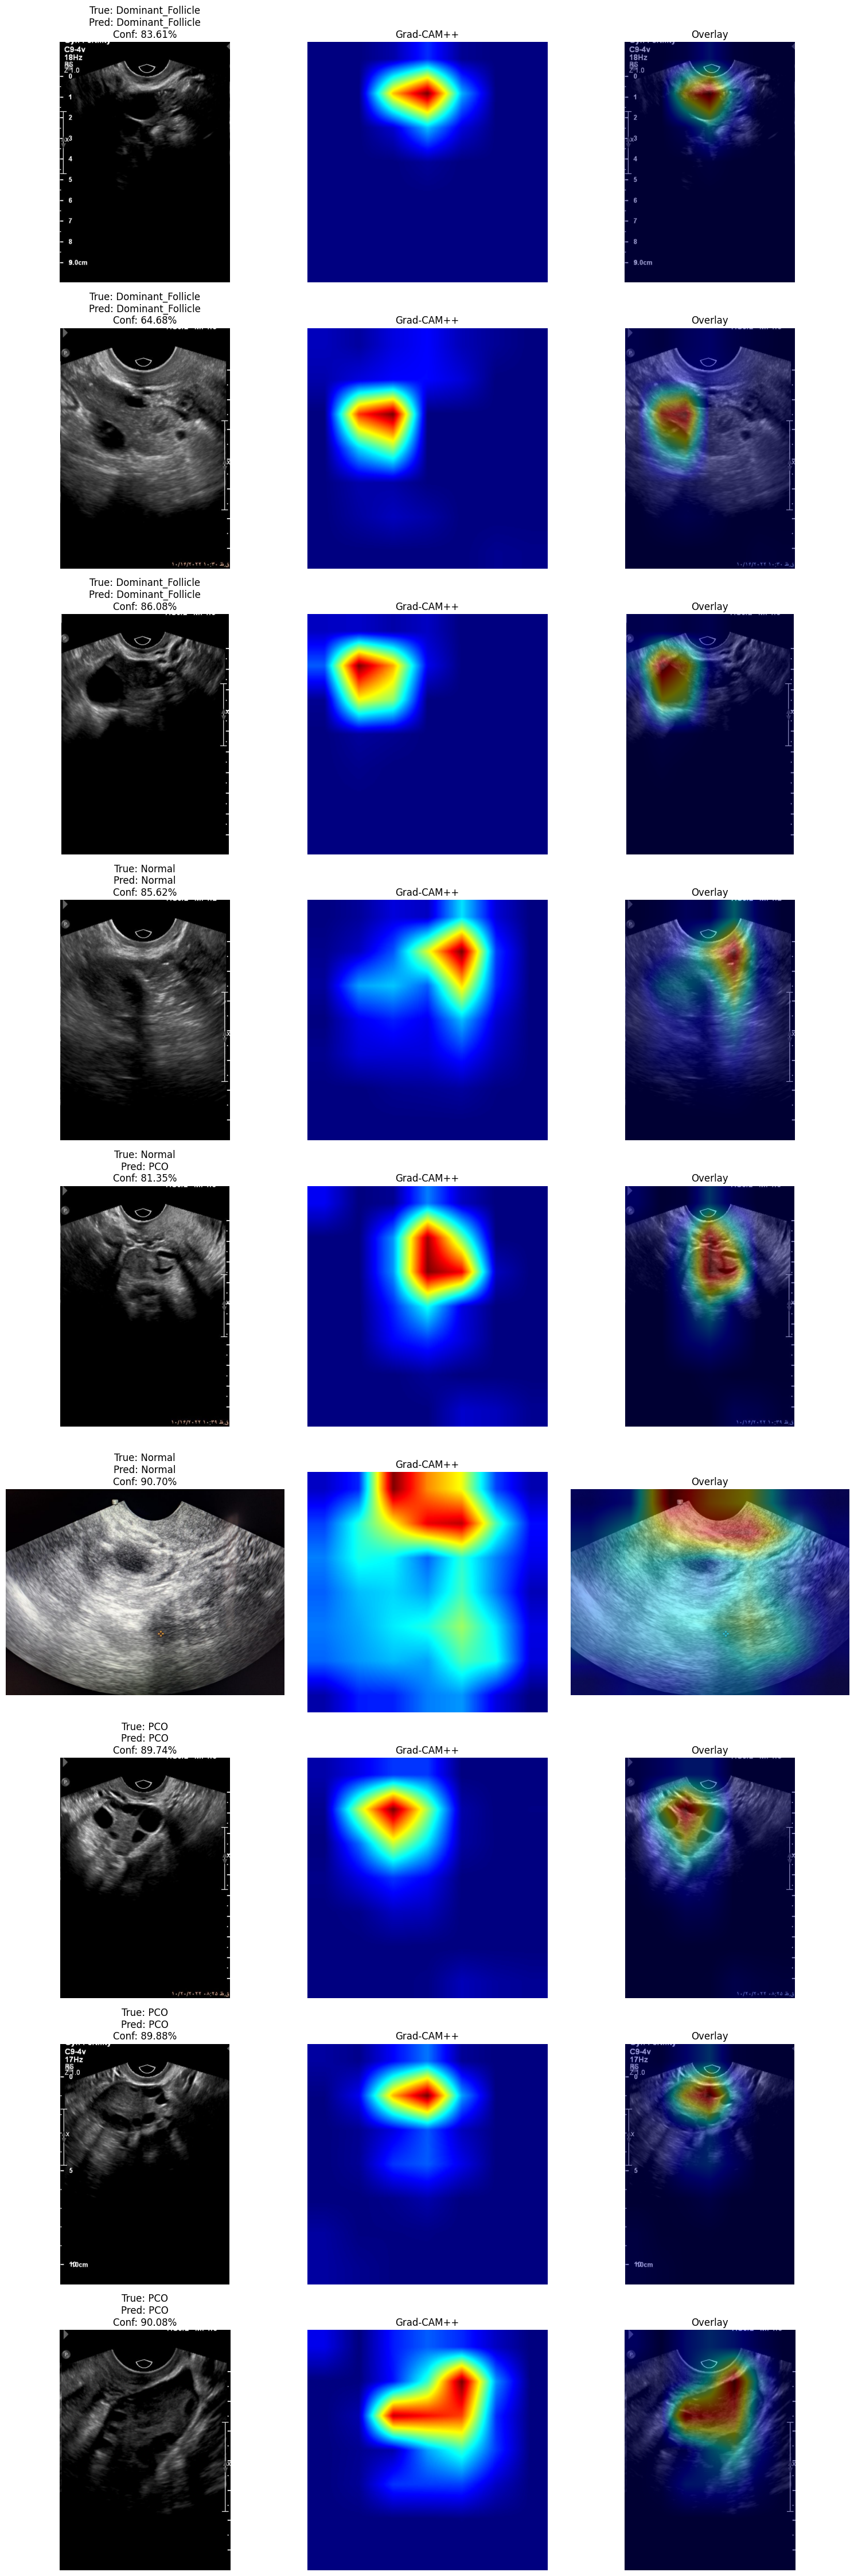

In [16]:
# ==========================================================
# FINAL GRAD-CAM++ (ERROR-FREE VERSION)
# ==========================================================

!pip install grad-cam -q

import torch
import torch.nn as nn
import numpy as np
import os
import cv2
import random
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.models import convnext_tiny
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# PATHS
# ========================
BASE_PATH = "/kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset"
MODEL_PATH = "/kaggle/working/convnext_40.pth"

# ========================
# FIND ROOT
# ========================
def find_root(root):
    for r, d, f in os.walk(root):
        if any(x.endswith((".jpg",".png",".jpeg")) for x in f):
            return os.path.dirname(r)
    return root

DATASET_ROOT = find_root(BASE_PATH)

classes = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Classes:", classes)

# ========================
# GET IMAGES
# ========================
def get_images(root, n=3):
    data = {}
    for cls in classes:
        cls_path = os.path.join(root, cls)

        imgs = []
        for r, _, f in os.walk(cls_path):
            for file in f:
                if file.endswith((".jpg",".png",".jpeg")):
                    imgs.append(os.path.join(r, file))

        if imgs:
            data[cls] = random.sample(imgs, min(n, len(imgs)))
    return data

data = get_images(DATASET_ROOT, 3)

# ========================
# TRANSFORM
# ========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# LOAD MODEL
# ========================
def load_model(path):
    checkpoint = torch.load(path, map_location=device)

    model = convnext_tiny(weights=None)
    num_classes = checkpoint["classifier.2.weight"].shape[0]

    model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model

model = load_model(MODEL_PATH)

# ========================
# 🔥 IMPORTANT LAYER FIX
# ========================
target_layers = [model.features[-1]]

cam = GradCAMPlusPlus(
    model=model,
    target_layers=target_layers
)

# ========================
# PLOT
# ========================
rows = sum(len(v) for v in data.values())

plt.figure(figsize=(15, 5 * rows))
row = 1

for class_name, imgs in data.items():

    for path in imgs:

        img = Image.open(path).convert("RGB")
        original = np.array(img)

        resized = img.resize((224,224))
        img_np = np.array(resized).astype(np.float32)/255.0

        input_tensor = transform(img).unsqueeze(0).to(device)

        # ========================
        # PREDICTION
        # ========================
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)

        pred_idx = pred.item()
        confidence = conf.item()*100
        pred_label = classes[pred_idx]

        # ========================
        # GRAD-CAM++
        # ========================
        targets = [ClassifierOutputTarget(pred_idx)]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        # ========================
        # HEATMAP
        # ========================
        heatmap = cv2.resize(grayscale_cam, (224,224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # ========================
        # OVERLAY
        # ========================
        heatmap_full = cv2.resize(
            grayscale_cam,
            (original.shape[1], original.shape[0])
        )
        heatmap_full = np.uint8(255 * heatmap_full)
        heatmap_full = cv2.applyColorMap(heatmap_full, cv2.COLORMAP_JET)

        overlay = heatmap_full * 0.4 + original * 0.6
        overlay = np.uint8(overlay)

        title = f"True: {class_name}\nPred: {pred_label}\nConf: {confidence:.2f}%"

        # ========================
        # PLOT
        # ========================
        plt.subplot(rows, 3, row)
        plt.title(title)
        plt.imshow(original)
        plt.axis("off")

        plt.subplot(rows, 3, row+1)
        plt.title("Grad-CAM++")
        plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.subplot(rows, 3, row+2)
        plt.title("Overlay")
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        row += 3

plt.tight_layout()
plt.show()

Classes: ['Dominant_Follicle', 'Normal', 'PCO']
--------------------------------------------------
Image: /kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset/ovarian_ultrasound_dataset/Dominant_Follicle/Dominant_Follicle_2.jpg
Actual Class    : Dominant_Follicle
Predicted Class : Dominant_Follicle
Confidence      : 72.23%
--------------------------------------------------
Image: /kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset/ovarian_ultrasound_dataset/Dominant_Follicle/Dominant_Follicle_25.jpg
Actual Class    : Dominant_Follicle
Predicted Class : Dominant_Follicle
Confidence      : 86.22%
--------------------------------------------------
Image: /kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset/ovarian_ultrasound_dataset/Dominant_Follicle/Dominant_Follicle_137.jpg
Actual Class    : Dominant_Follicle
Predicted Class : Dominant_Follicle
Confidence      : 84.73%
--------------------------------------------------
Image: /kaggle/i

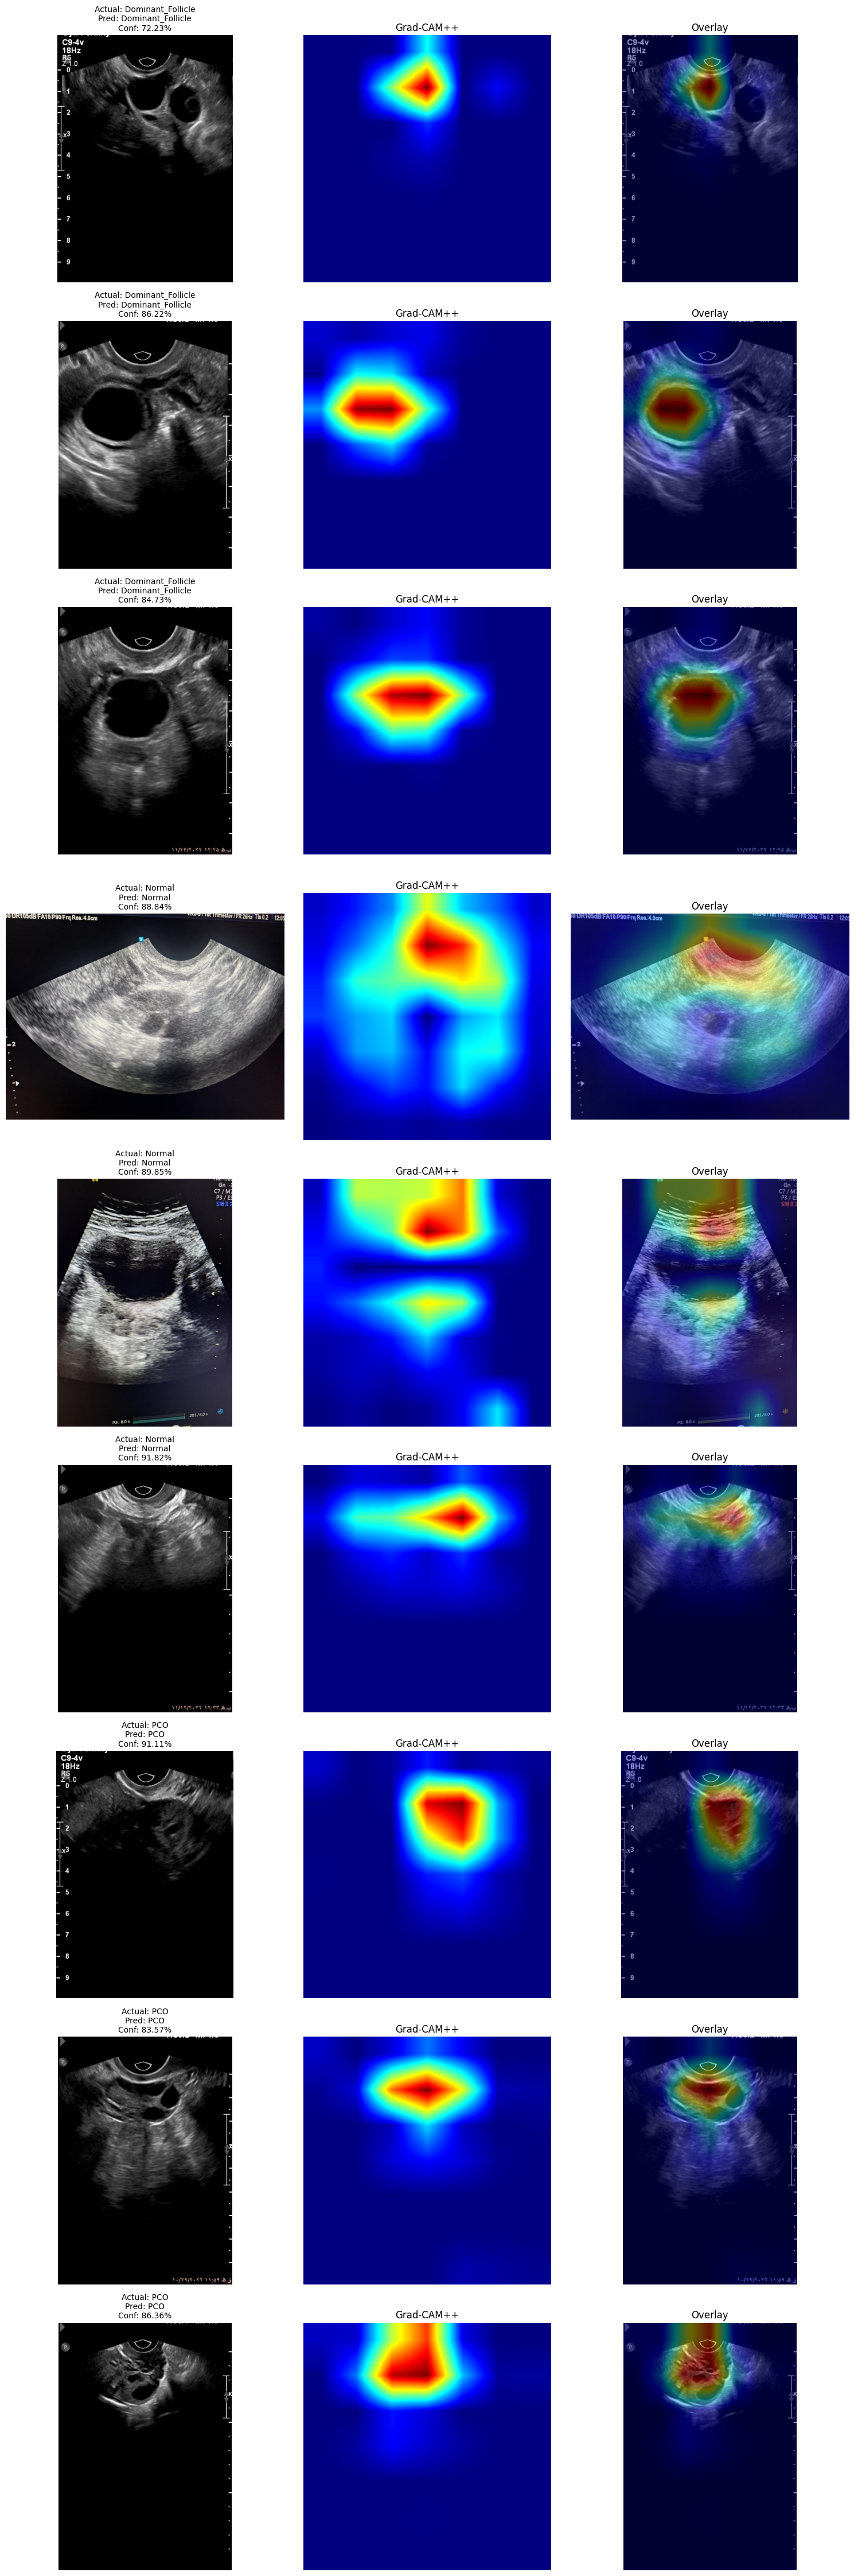

In [17]:
# ==========================================================
# FINAL: GRAD-CAM++ WITH CLEAR OUTPUT (PRINT + VISUAL)
# ==========================================================

import torch
import torch.nn as nn
import numpy as np
import os
import cv2
import random
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.models import convnext_tiny
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# PATHS
# ========================
BASE_PATH = "/kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset"
MODEL_PATH = "/kaggle/working/convnext_40.pth"

# ========================
# FIND ROOT
# ========================
def find_root(root):
    for r, d, f in os.walk(root):
        if any(x.endswith((".jpg",".png",".jpeg")) for x in f):
            return os.path.dirname(r)
    return root

DATASET_ROOT = find_root(BASE_PATH)

classes = sorted([
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
])

print("Classes:", classes)

# ========================
# GET IMAGES
# ========================
def get_images(root, n=3):
    data = {}
    for cls in classes:
        cls_path = os.path.join(root, cls)

        imgs = []
        for r, _, f in os.walk(cls_path):
            for file in f:
                if file.endswith((".jpg",".png",".jpeg")):
                    imgs.append(os.path.join(r, file))

        if imgs:
            data[cls] = random.sample(imgs, min(n, len(imgs)))
    return data

data = get_images(DATASET_ROOT, 3)

# ========================
# TRANSFORM
# ========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# LOAD MODEL
# ========================
def load_model(path):
    checkpoint = torch.load(path, map_location=device)

    model = convnext_tiny(weights=None)
    num_classes = checkpoint["classifier.2.weight"].shape[0]

    model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
    model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()
    return model

model = load_model(MODEL_PATH)

# ========================
# GRAD-CAM++
# ========================
target_layers = [model.features[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)

# ========================
# PLOT
# ========================
rows = sum(len(v) for v in data.values())

plt.figure(figsize=(15, 5 * rows))
row = 1

for class_name, imgs in data.items():

    for path in imgs:

        img = Image.open(path).convert("RGB")
        original = np.array(img)

        resized = img.resize((224,224))
        img_np = np.array(resized).astype(np.float32)/255.0

        input_tensor = transform(img).unsqueeze(0).to(device)

        # ========================
        # PREDICTION
        # ========================
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)

        conf, pred = torch.max(probs, 1)
        pred_idx = pred.item()
        confidence = conf.item() * 100

        pred_label = classes[pred_idx]
        true_label = class_name

        # 👉 PRINT OUTPUT (IMPORTANT)
        print("--------------------------------------------------")
        print(f"Image: {path}")
        print(f"Actual Class    : {true_label}")
        print(f"Predicted Class : {pred_label}")
        print(f"Confidence      : {confidence:.2f}%")

        # ========================
        # GRAD-CAM++
        # ========================
        targets = [ClassifierOutputTarget(pred_idx)]

        grayscale_cam = cam(
            input_tensor=input_tensor,
            targets=targets
        )[0]

        # HEATMAP
        heatmap = cv2.resize(grayscale_cam, (224,224))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # OVERLAY
        heatmap_full = cv2.resize(grayscale_cam,
                                 (original.shape[1], original.shape[0]))
        heatmap_full = np.uint8(255 * heatmap_full)
        heatmap_full = cv2.applyColorMap(heatmap_full, cv2.COLORMAP_JET)

        overlay = heatmap_full * 0.4 + original * 0.6
        overlay = np.uint8(overlay)

        # ========================
        # TITLE (VISIBLE)
        # ========================
        title = (
            f"Actual: {true_label}\n"
            f"Pred: {pred_label}\n"
            f"Conf: {confidence:.2f}%"
        )

        # ========================
        # PLOT
        # ========================
        plt.subplot(rows, 3, row)
        plt.title(title, fontsize=10)
        plt.imshow(original)
        plt.axis("off")

        plt.subplot(rows, 3, row+1)
        plt.title("Grad-CAM++")
        plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.subplot(rows, 3, row+2)
        plt.title("Overlay")
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        row += 3

plt.tight_layout()
plt.show()

Classes: ['Dominant_Follicle', 'Normal', 'PCO']

Accuracy: 91.36%

Classification Report:
                   precision    recall  f1-score   support

Dominant_Follicle       0.95      0.89      0.92       144
           Normal       0.97      0.95      0.96        41
              PCO       0.86      0.93      0.89       116

         accuracy                           0.91       301
        macro avg       0.93      0.92      0.92       301
     weighted avg       0.92      0.91      0.91       301



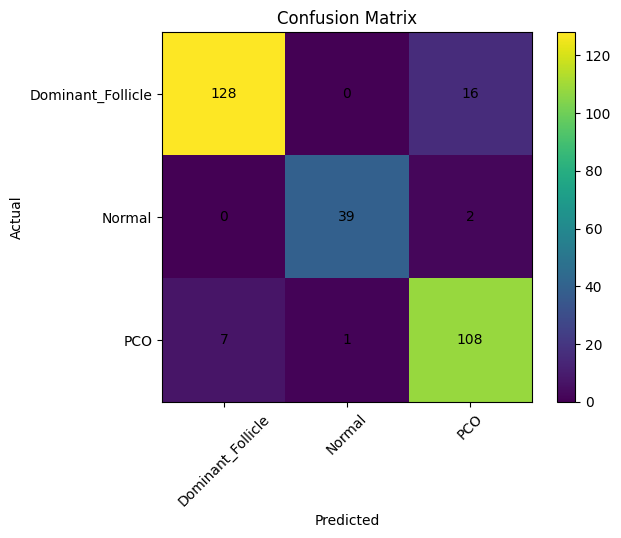

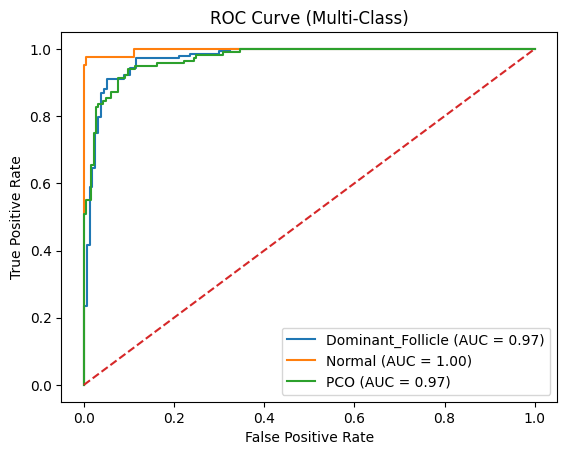

In [18]:
# ==========================================================
# FINAL EVALUATION: ROC + CONFUSION MATRIX + METRICS
# ==========================================================

import torch
import numpy as np
import os
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.models import convnext_tiny

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    classification_report, accuracy_score
)
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ========================
# PATHS
# ========================
DATASET_PATH = "/kaggle/input/datasets/baizidmdashadzzaman/ovarian-ultrasound-dataset/ovarian_ultrasound_dataset"
MODEL_PATH = "/kaggle/working/convnext_40.pth"

# ========================
# TRANSFORM
# ========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ========================
# DATASET
# ========================
dataset = ImageFolder(DATASET_PATH, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

classes = dataset.classes
num_classes = len(classes)

print("Classes:", classes)

# ========================
# LOAD MODEL
# ========================
def load_model(path):
    checkpoint = torch.load(path, map_location=device)

    model = convnext_tiny(weights=None)
    model.classifier[2] = torch.nn.Linear(
        model.classifier[2].in_features,
        num_classes
    )

    model.load_state_dict(checkpoint)
    model.to(device)
    model.eval()

    return model

model = load_model(MODEL_PATH)

# ========================
# PREDICTION LOOP
# ========================
all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
all_preds = np.array(all_preds)

# ========================
# ACCURACY
# ========================
acc = accuracy_score(all_labels, all_preds) * 100
print(f"\nAccuracy: {acc:.2f}%")

# ========================
# CLASSIFICATION REPORT
# ========================
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# ========================
# CONFUSION MATRIX
# ========================
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(num_classes), classes, rotation=45)
plt.yticks(range(num_classes), classes)

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ========================
# ROC CURVE (MULTI-CLASS)
# ========================
# One-vs-Rest
y_true_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-Class)")
plt.legend()
plt.show()